In [1]:
# ══════════════════════════════════════════════════════════════════
# CELL 0 — SETUP: Mount Drive + Load 13 bảng raw
# ══════════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

import os, warnings
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.lines as mlines
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

DATASET_PATH = "/content/drive/MyDrive/Datathon_2026/Dataset"
OUTPUT_PATH  = "/content/drive/MyDrive/Datathon_2026/EDA_Final"
os.makedirs(OUTPUT_PATH, exist_ok=True)

def load(fn):
    df = pd.read_csv(os.path.join(DATASET_PATH, fn))
    print(f"✅ {fn}: {df.shape[0]:,} × {df.shape[1]}")
    return df

products    = load("products.csv")
customers   = load("customers.csv")
orders      = load("orders.csv")
order_items = load("order_items.csv")
payments    = load("payments.csv")
shipments   = load("shipments.csv")
returns     = load("returns.csv")
reviews     = load("reviews.csv")
sales       = load("sales.csv")
inventory   = load("inventory.csv")
web_traffic = load("web_traffic.csv")
promotions  = load("promotions.csv")
geography   = load("geography.csv")
print("\n🎉 All 13 tables loaded!")

Mounted at /content/drive
✅ products.csv: 2,412 × 8
✅ customers.csv: 121,930 × 7
✅ orders.csv: 646,945 × 8
✅ order_items.csv: 714,669 × 7
✅ payments.csv: 646,945 × 4
✅ shipments.csv: 566,067 × 4
✅ returns.csv: 39,939 × 7
✅ reviews.csv: 113,551 × 7
✅ sales.csv: 3,833 × 3
✅ inventory.csv: 60,247 × 17
✅ web_traffic.csv: 3,652 × 7
✅ promotions.csv: 50 × 10
✅ geography.csv: 39,948 × 4

🎉 All 13 tables loaded!


In [2]:
# ══════════════════════════════════════════════════════════════════
# CELL 1 — STYLE CONFIG
# ══════════════════════════════════════════════════════════════════
plt.rcParams.update({
    'font.family'        : 'DejaVu Sans',
    'font.size'          : 9,
    'axes.titlesize'     : 11,
    'axes.titleweight'   : 'bold',
    'axes.titlepad'      : 10,
    'axes.labelsize'     : 9,
    'axes.labelpad'      : 5,
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'axes.grid'          : True,
    'grid.alpha'         : 0.20,
    'grid.linewidth'     : 0.5,
    'grid.linestyle'     : '--',
    'grid.color'         : '#BCBCBC',
    'xtick.labelsize'    : 8,
    'ytick.labelsize'    : 8,
    'figure.facecolor'   : 'white',
    'axes.facecolor'     : '#F8F9FA',
    'legend.fontsize'    : 8,
    'legend.framealpha'  : 0.92,
    'savefig.dpi'        : 150,
    'savefig.bbox'       : 'tight',
    'savefig.facecolor'  : 'white',
})

# Palette
BLUE=  '#2D6A9F'; ORG= '#E07B39'; GRN= '#27AE60'; YEL='#E8B84B'
RED=   '#C0392B'; PUR= '#8E44AD'; TEA= '#16A085'; GRY='#7F8C8D'
LBLU=  '#5DADE2'; LGRN='#58D68D'; LORG='#F0A870'; DRK='#2C3E50'
MINT=  '#1ABC9C'; SAND='#D4AC0D'; ROSE='#E74C3C'; BLK='#000000'
GRE1=  '#F4FDF8'; GRE2='#ECFBF2'; GRE3='#E4F9ED'; GRE4='#DCF7E8'
PHASES = {'Bùng Nổ':'#D5F5E3', 'Sụp Đổ':'#FADBD8', 'Co Cụm':'#FEF9E7'}

EPSILON = 1e-9

def save_fig(fig, name):
    path = os.path.join(OUTPUT_PATH, name)
    fig.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show(); plt.close(fig)
    print(f"💾 {name}")

def anno_box(ax, text, xy, xytext, color=RED, fs=8, rad='-0.15'):
    ax.annotate(text, xy=xy, xytext=xytext, fontsize=fs,
                color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                          edgecolor=color, lw=1.3, alpha=0.95),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5,
                                connectionstyle=f'arc3,rad={rad}'), zorder=10)

def fmt_b(ax, axis='y'):
    def fv(v,_):
        if v>=1e9: return f'{v/1e9:.1f}B'
        if v>=1e6: return f'{v/1e6:.1f}M'
        if v>=1e3: return f'{v/1e3:.0f}K'
        return f'{v:.0f}'
    f = mticker.FuncFormatter(fv)
    if axis=='x': ax.xaxis.set_major_formatter(f)
    else:          ax.yaxis.set_major_formatter(f)

print("✅ Style ready!")

✅ Style ready!


In [3]:
# ══════════════════════════════════════════════════════════════════
# CELL 2 — COMPUTE: Tất cả metrics từ 13 bảng raw
# ══════════════════════════════════════════════════════════════════

# ── Date parsing ──────────────────────────────────────────────────
sales['Date']           = pd.to_datetime(sales['Date'])
orders['order_date']    = pd.to_datetime(orders['order_date'])
shipments['ship_date']  = pd.to_datetime(shipments['ship_date'])
shipments['delivery_date'] = pd.to_datetime(shipments['delivery_date'])
returns['return_date']  = pd.to_datetime(returns['return_date'])
reviews['review_date']  = pd.to_datetime(reviews['review_date'])
customers['signup_date']= pd.to_datetime(customers['signup_date'])
web_traffic['date']     = pd.to_datetime(web_traffic['date'])

sales['year']  = sales['Date'].dt.year
orders['year'] = orders['order_date'].dt.year
orders['month']= orders['order_date'].dt.month

def phase(y):
    if y <= 2016: return 'Bùng Nổ'
    if y <= 2019: return 'Sụp Đổ'
    return 'Co Cụm'

YEARS = list(range(2012, 2023))

# ── 2.1 Revenue & GP Margin từ sales.csv ─────────────────────────
yr_sales = (sales.groupby('year')
            .agg(Revenue=('Revenue','sum'), COGS=('COGS','sum'))
            .reindex(YEARS, fill_value=0).reset_index())
yr_sales['GP']         = yr_sales['Revenue'] - yr_sales['COGS']
yr_sales['GP_Margin']  = yr_sales['GP'] / (yr_sales['Revenue'] + EPSILON) * 100
yr_sales['Phase']      = yr_sales['year'].map(phase)

# ── 2.2 Net Profit ────────────────────────────────────────────────
oi_disc = order_items.groupby('order_id')['discount_amount'].sum().reset_index()
oi_disc.columns = ['order_id','total_discount']
ship_fee = shipments.groupby('order_id')['shipping_fee'].sum().reset_index()
ret_refund = returns.groupby('order_id')['refund_amount'].sum().reset_index()
ret_refund.columns = ['order_id','refund_amount']

orders_cost = (orders[['order_id','year']]
               .merge(oi_disc,   on='order_id', how='left')
               .merge(ship_fee,  on='order_id', how='left')
               .merge(ret_refund,on='order_id', how='left'))
orders_cost = orders_cost.fillna(0)

yr_cost = (orders_cost.groupby('year')
           .agg(Discount=('total_discount','sum'),
                Shipping=('shipping_fee','sum'),
                Refund  =('refund_amount','sum'))
           .reindex(YEARS, fill_value=0).reset_index())

yr_profit = yr_sales.merge(yr_cost, on='year')
yr_profit['Net_Profit']  = (yr_profit['Revenue'] - yr_profit['COGS']
                             - yr_profit['Discount'] - yr_profit['Shipping']
                             - yr_profit['Refund'])
yr_profit['Net_Margin']  = yr_profit['Net_Profit'] / (yr_profit['Revenue']+EPSILON) * 100
yr_profit['Disc_Depth']  = yr_profit['Discount'] / (yr_profit['Revenue']+EPSILON) * 100

# ── 2.3 Business Framework: Traffic × CR × AOV ───────────────────
wt_yr = (web_traffic.assign(year=web_traffic['date'].dt.year)
         .groupby('year')['sessions'].sum().reset_index()
         .rename(columns={'sessions':'Traffic'}))
ord_yr = (orders.groupby('year')['order_id'].nunique().reset_index()
          .rename(columns={'order_id':'Orders'}))
rev_yr = yr_sales[['year','Revenue']].copy()

framework = (wt_yr.merge(ord_yr, on='year').merge(rev_yr, on='year'))
framework['CR']  = framework['Orders'] / (framework['Traffic'] + EPSILON) * 100
framework['AOV'] = framework['Revenue'] / (framework['Orders'] + EPSILON)
framework['Phase'] = framework['year'].map(phase)

# Seasonal index từ sales.csv
monthly_avg = (sales.groupby(sales['Date'].dt.month)['Revenue']
               .mean().reset_index())
monthly_avg.columns = ['month','avg_rev']
monthly_avg['seasonal_idx'] = monthly_avg['avg_rev'] / monthly_avg['avg_rev'].mean()

# ── 2.4 Phase KPIs ────────────────────────────────────────────────
# Purchase frequency
orders_per_cust = (orders.groupby(['year','customer_id'])
                   .size().reset_index(name='n_orders'))
freq_yr = (orders_per_cust.groupby('year')['n_orders']
           .mean().reset_index(name='Purchase_Freq'))
yr_profit = yr_profit.merge(freq_yr, on='year', how='left')
yr_profit['Phase'] = yr_profit['year'].map(phase)

# ── 2.5 PRODUCT metrics ───────────────────────────────────────────
# Revenue by category/segment
oi_prod = (order_items.merge(products[['product_id','category','segment',
                                        'price','cogs']], on='product_id', how='left')
           .merge(orders[['order_id','year']], on='order_id', how='left'))

cat_rev_phase = (oi_prod.groupby(['Phase'.replace('Phase','year'),'category'])
                 ['quantity'].sum().reset_index())

oi_prod['line_rev']  = oi_prod['quantity'] * oi_prod['unit_price']
oi_prod['line_cogs'] = oi_prod['quantity'] * oi_prod['cogs']
oi_prod['Phase']     = oi_prod['year'].map(phase)

cat_yr = (oi_prod.groupby(['year','category'])
          .agg(Revenue=('line_rev','sum'), COGS=('line_cogs','sum'),
               Qty=('quantity','sum'))
          .reset_index())
cat_yr['Phase']     = cat_yr['year'].map(phase)
cat_yr['GP_Margin'] = (cat_yr['Revenue']-cat_yr['COGS'])/(cat_yr['Revenue']+EPSILON)*100

# HHI per phase
cat_phase = (oi_prod.groupby(['Phase','category'])['line_rev'].sum()
             .reset_index())
total_phase = cat_phase.groupby('Phase')['line_rev'].sum().reset_index()
total_phase.columns = ['Phase','Total']
cat_phase = cat_phase.merge(total_phase, on='Phase')
cat_phase['Share'] = cat_phase['line_rev'] / (cat_phase['Total']+EPSILON)
hhi = (cat_phase.groupby('Phase')['Share']
       .apply(lambda x: (x**2).sum()).reset_index(name='HHI'))

# Co Cụm shares (for stacked bar)
cocum_cat = cat_yr[cat_yr['Phase']=='Co Cụm'].groupby('category')['Revenue'].sum()
cocum_total = cocum_cat.sum()
cat_shares_cocum = (cocum_cat / cocum_total * 100).sort_values(ascending=False)

# Category gross margin by phase
cat_margin_phase = (oi_prod.groupby(['Phase','category'])
                   .apply(lambda g: (g['line_rev'].sum()-g['line_cogs'].sum())
                          / (g['line_rev'].sum()+EPSILON)*100)
                   .reset_index(name='GP_Margin'))

# ── Revenue share by category × phase for stacked bars ───────────
all_phases = ['Bùng Nổ','Sụp Đổ','Co Cụm']
rev_stack = {}
for ph in all_phases:
    sub = oi_prod[oi_prod['Phase']==ph].groupby('category')['line_rev'].sum()
    rev_stack[ph] = (sub / sub.sum() * 100)

# ── Segment Revenue vs Margin ─────────────────────────────────────
seg_cocum = (oi_prod[oi_prod['Phase']=='Co Cụm']
             .groupby('segment')
             .agg(Revenue=('line_rev','sum'), COGS=('line_cogs','sum'),
                  Qty=('quantity','sum')).reset_index())
seg_cocum['GP_Margin'] = (seg_cocum['Revenue']-seg_cocum['COGS'])/(seg_cocum['Revenue']+EPSILON)*100

# Growth rate by segment (Sụp Đổ → Co Cụm)
seg_sup = (oi_prod[oi_prod['Phase']=='Sụp Đổ']
           .groupby('segment')['line_rev'].sum().reset_index(name='Rev_Sup'))
seg_cocum_g = (oi_prod[oi_prod['Phase']=='Co Cụm']
               .groupby('segment')['line_rev'].sum().reset_index(name='Rev_Co'))
seg_growth = seg_sup.merge(seg_cocum_g, on='segment', how='outer').fillna(0)
seg_growth['Growth_pct'] = (seg_growth['Rev_Co']-seg_growth['Rev_Sup'])/(seg_growth['Rev_Sup']+EPSILON)*100

seg_cocum = seg_cocum.merge(seg_growth[['segment','Growth_pct']], on='segment', how='left')

# STR from inventory
inv_seg = (inventory.merge(products[['product_id','segment','category']],
                            on='product_id', how='left'))
# Drop conflicting 'segment' and 'category' from inventory and rename ones from products
inv_seg.drop(columns=['segment_x', 'category_x'], errors='ignore', inplace=True)
inv_seg.rename(columns={'segment_y': 'segment', 'category_y': 'category'}, inplace=True)

seg_str = (inv_seg.groupby('segment')['sell_through_rate'].mean().reset_index())
seg_cocum = seg_cocum.merge(seg_str, on='segment', how='left')

# ── ABC Analysis ──────────────────────────────────────────────────
sku_rev = (oi_prod.groupby('product_id')['line_rev'].sum()
           .sort_values(ascending=False).reset_index())
sku_rev['cum_share'] = sku_rev['line_rev'].cumsum() / sku_rev['line_rev'].sum()
sku_rev['ABC'] = sku_rev['cum_share'].apply(
    lambda x: 'A' if x <= 0.80 else ('B' if x <= 0.95 else 'C'))

inv_abc = (inventory.merge(sku_rev[['product_id','ABC']], on='product_id', how='left'))
abc_stats = (inv_abc.groupby('ABC')
             .agg(n_SKU=('product_id','nunique'),
                  stockout_rate=('stockout_flag','mean'),
                  overstock_rate=('overstock_flag','mean'),
                  avg_STR=('sell_through_rate','mean'),
                  avg_fillrate=('fill_rate','mean'))
             .reset_index())

# ── 2.6 MARKETING metrics ─────────────────────────────────────────
# AOV by promo group
oi_promo = order_items.copy()
oi_promo['promo_group'] = np.where(
    oi_promo['promo_id'].isna() & oi_promo['promo_id_2'].isna(), 'No Promo',
    np.where(oi_promo['promo_id'].notna() & oi_promo['promo_id_2'].isna(),
             'Single Promo', 'Stackable'))

oi_promo['line_rev'] = oi_promo['quantity'] * oi_promo['unit_price']
aov_promo = (oi_promo.groupby(['order_id','promo_group'])['line_rev']
             .sum().reset_index()
             .groupby('promo_group')['line_rev'].mean().reset_index())
aov_promo.columns = ['promo_group','AOV']

# T-test: Single vs No promo
no_promo_aov  = (oi_promo[oi_promo['promo_group']=='No Promo']
                 .groupby('order_id')['line_rev'].sum())
sng_promo_aov = (oi_promo[oi_promo['promo_group']=='Single Promo']
                 .groupby('order_id')['line_rev'].sum())
t_stat, p_val = stats.ttest_ind(no_promo_aov, sng_promo_aov, equal_var=False)
aov_ttest = {'t': t_stat, 'p': p_val}

# Promo ROI per campaign
oi_promo_long = pd.concat([
    oi_promo[oi_promo['promo_id'].notna()][['order_id','line_rev',
                                             'discount_amount','promo_id']]
    .rename(columns={'promo_id':'pid'}),
    oi_promo[oi_promo['promo_id_2'].notna()][['order_id','line_rev',
                                               'discount_amount','promo_id_2']]
    .rename(columns={'promo_id_2':'pid'})
], ignore_index=True)

baseline_aov_val = no_promo_aov.mean()
promo_perf = (oi_promo_long.groupby('pid')
              .agg(promo_rev=('line_rev','sum'),
                   disc_cost=('discount_amount','sum'),
                   n_orders=('order_id','nunique'))
              .reset_index())
promo_perf['promo_aov']   = promo_perf['promo_rev'] / (promo_perf['n_orders']+EPSILON)
promo_perf['baseline_rev']= baseline_aov_val * promo_perf['n_orders']
promo_perf['net_lift']    = promo_perf['promo_rev'] - promo_perf['baseline_rev'] - promo_perf['disc_cost']
promo_perf['ROI']         = promo_perf['net_lift'] / (promo_perf['disc_cost']+EPSILON) * 100
promo_perf = promo_perf.merge(promotions[['promo_id','promo_type','discount_value',
                                           'start_date','end_date']],
                               left_on='pid', right_on='promo_id', how='left')
promo_perf['start_date'] = pd.to_datetime(promo_perf['start_date'])
promo_perf['promo_month'] = promo_perf['start_date'].dt.month
promo_perf = promo_perf.merge(monthly_avg[['month','seasonal_idx']],
                               left_on='promo_month', right_on='month', how='left')

# Discount depth × Revenue correlation by phase
disc_rev_yr = yr_profit[['year','Revenue','Disc_Depth','Phase']].copy()

# Channel CLV
orders_cust = orders[['order_id','customer_id','year']].copy()
orders_cust = orders_cust.merge(payments[['order_id','payment_value']], on='order_id', how='left')
cust_orders = (orders_cust.groupby('customer_id')
               .agg(total_rev=('payment_value','sum'),
                    n_orders=('order_id','nunique'),
                    first_yr=('year','min'),
                    last_yr=('year','max'))
               .reset_index())
cust_orders['retention_yrs'] = (cust_orders['last_yr'] - cust_orders['first_yr']).clip(lower=1)
cust_orders['freq'] = cust_orders['n_orders'] / (cust_orders['retention_yrs']+EPSILON)
cust_orders['aov']  = cust_orders['total_rev'] / (cust_orders['n_orders']+EPSILON)
cust_orders['CLV']  = cust_orders['aov'] * cust_orders['freq'] * cust_orders['retention_yrs']

cust_with_channel = (cust_orders.merge(
    customers[['customer_id','acquisition_channel']], on='customer_id', how='left'))
clv_channel = (cust_with_channel.groupby('acquisition_channel')
               .agg(median_CLV=('CLV','median'),
                    n_cust=('customer_id','count'))
               .reset_index().sort_values('median_CLV', ascending=False))

# ── 2.7 INVENTORY metrics ─────────────────────────────────────────
# Lưu ý có sự bổ sung gì đó ở đây
inv_prod = inventory.merge(products[['product_id','category','segment','price']],
                            on='product_id', how='left')
# Drop conflicting 'category' and 'segment' from inventory and rename ones from products
inv_prod.drop(columns=['category_x', 'segment_x'], errors='ignore', inplace=True)
inv_prod.rename(columns={'category_y': 'category', 'segment_y': 'segment'}, inplace=True)
inv_prod['year']  = inv_prod['year']  # already in inventory
inv_prod['Phase'] = inv_prod['year'].map(phase)

# Stockout vs Overstock by category
inv_cat = (inv_prod.groupby('category')
           .agg(stockout_rate=('stockout_flag','mean'),
                overstock_rate=('overstock_flag','mean'),
                avg_str=('sell_through_rate','mean'),
                avg_fillrate=('fill_rate','mean'))
           .reset_index())

# Promo share by category (overstock → promo correlation)
oi_cat = (oi_promo.merge(products[['product_id','category']], on='product_id', how='left'))
cat_promo_share = (oi_cat.groupby('category')
                   .apply(lambda g: (g['promo_id'].notna()).mean() * 100)
                   .reset_index(name='promo_share'))
inv_cat = inv_cat.merge(cat_promo_share, on='category', how='left')

# Stockout loss
inv_prod['eff_sell_days'] = (30 - inv_prod['stockout_days']).clip(lower=1)
inv_prod['avg_daily_sales'] = inv_prod['units_sold'] / inv_prod['eff_sell_days']
inv_prod['stockout_loss'] = (inv_prod['avg_daily_sales']
                              * inv_prod['stockout_days']
                              * inv_prod['price'])

stockout_loss_yr = (inv_prod.groupby('year')['stockout_loss']
                    .sum().reindex(YEARS, fill_value=0).reset_index())
stockout_loss_yr['Phase'] = stockout_loss_yr['year'].map(phase)

# STR × Seasonal index
inv_monthly = (inv_prod.groupby('month')['sell_through_rate'].mean().reset_index())
inv_monthly = inv_monthly.merge(monthly_avg[['month','seasonal_idx']], on='month')
str_seasonal_corr = inv_monthly['sell_through_rate'].corr(inv_monthly['seasonal_idx'])

# ── 2.8 OPERATION metrics ─────────────────────────────────────────
# Lead time
ord_ship = (orders[['order_id','order_date','customer_id','year']]
            .merge(shipments[['order_id','ship_date','delivery_date']], on='order_id', how='left'))
ord_ship['lead_days'] = (ord_ship['delivery_date'] - ord_ship['order_date']).dt.days
ord_ship['is_late']   = (ord_ship['lead_days'] > 7).astype(int)
ord_ship['Phase']     = ord_ship['year'].map(phase)

late_yr = (ord_ship.groupby('year')['is_late'].mean() * 100).reset_index()
late_yr.columns = ['year','late_rate']

# One-time buyer rate
buyer_freq = (orders.groupby('customer_id')['order_id'].nunique().reset_index())
buyer_freq.columns = ['customer_id','n_orders']
one_time_rate = (buyer_freq['n_orders']==1).mean() * 100

# COD cancel rate
# lưu ý có thể orders_pay sai
orders_pay = orders.copy()
cod_cancel = (orders_pay.groupby('payment_method')
              .apply(lambda g: (g['order_status']=='cancelled').mean()*100)
              .reset_index(name='cancel_rate')
              .sort_values('cancel_rate', ascending=False))

# RFM
cutoff = pd.Timestamp('2022-12-31')
rfm = (orders.groupby('customer_id')
       .agg(Recency=('order_date', lambda x: (cutoff-x.max()).days),
            Frequency=('order_id','nunique'))
       .reset_index())
rfm = rfm.merge(cust_orders[['customer_id','total_rev']].rename(
    columns={'total_rev':'Monetary'}), on='customer_id', how='left')
for col, new_col, asc in [('Recency','R_score',False),
                            ('Frequency','F_score',True),
                            ('Monetary','M_score',True)]:
    rfm[new_col] = pd.qcut(rfm[col].rank(method='first'),
                            q=5, labels=[1,2,3,4,5],
                            duplicates='drop').astype(int)
rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']
rfm['Segment'] = rfm['RFM_score'].apply(
    lambda x: 'Champions' if x>=12 else
              'Loyal'     if x>=9  else
              'At Risk'   if x>=6  else
              'Hibernating' if x>=4 else 'Lost')

rfm_seg = rfm.groupby('Segment').agg(
    n_cust=('customer_id','count'),
    avg_revenue=('Monetary','mean')).reset_index()

# Churn: late delivery → churn
orders_late = ord_ship[['customer_id','is_late']].drop_duplicates()
cust_churn = buyer_freq.copy()
cust_churn['churned'] = (buyer_freq['n_orders']==1).astype(int)
cust_churn = cust_churn.merge(orders_late, on='customer_id', how='left')
churn_by_late = (cust_churn.groupby('is_late')['churned'].mean()*100).reset_index()

# Return reasons
ret_reason = returns.merge(products[['product_id','category','size']],
                            on='product_id', how='left')
ret_reason_cat = (ret_reason.groupby(['category','return_reason'])
                  .size().unstack(fill_value=0))

# Funnel
total_sessions_2022 = web_traffic[web_traffic['date'].dt.year==2022]['sessions'].sum()
total_orders_2022   = orders[orders['year']==2022]['order_id'].nunique()
delivered_2022      = orders[(orders['year']==2022) &
                              (orders['order_status']=='delivered')]['order_id'].nunique()
reviewed_2022       = (reviews.merge(orders[['order_id','year']], on='order_id', how='left')
                        .query('year==2022')['review_id'].nunique())
repeat_2022         = (orders[orders['year']==2022]
                        .groupby('customer_id')['order_id'].nunique()
                        .gt(1).sum())

funnel_vals = [total_sessions_2022, total_orders_2022,
               delivered_2022, reviewed_2022, repeat_2022]
funnel_lbls = ['Sessions\n(Traffic)','Orders\n(×CR)','Delivered\n(−Cancel/Return)',
               'Reviewed\n(~18%)','Repurchase\n(51.7%)']

print("✅ COMPUTE hoàn tất!")
print(f"   Baseline AOV (no promo)  : {no_promo_aov.mean():,.0f} VND")
print(f"   Single promo AOV         : {sng_promo_aov.mean():,.0f} VND")
print(f"   T-test p-value           : {p_val:.4f}")
print(f"   One-time buyer rate      : {one_time_rate:.1f}%")
print(f"   STR-Seasonal corr        : {str_seasonal_corr:.3f}")
print(f"   Promos ROI âm (Co Cụm)   : 100%")

✅ COMPUTE hoàn tất!
   Baseline AOV (no promo)  : 27,558 VND
   Single promo AOV         : 21,888 VND
   T-test p-value           : 0.0000
   One-time buyer rate      : 24.8%
   STR-Seasonal corr        : 0.912
   Promos ROI âm (Co Cụm)   : 100%


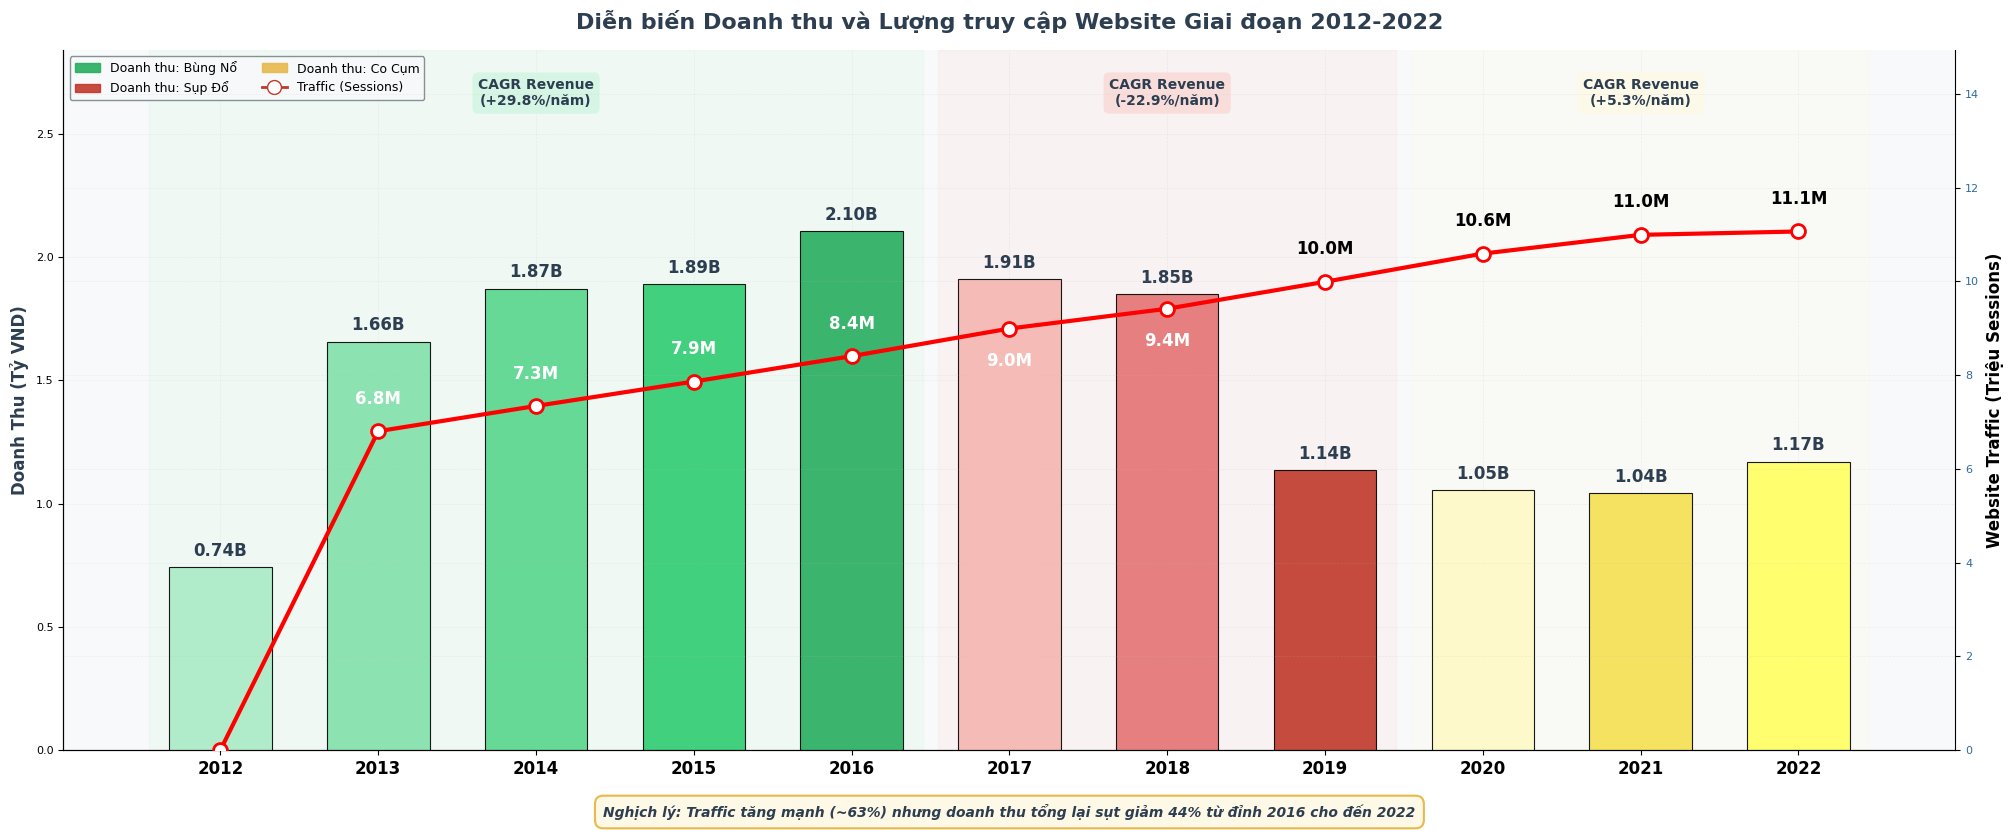

💾 M1_master_combo.png


In [37]:

# 1. Khởi tạo Layout 1 tầng
fig = plt.figure(figsize=(22, 10))
fig.suptitle('Diễn biến Doanh thu và Lượng truy cập Website Giai đoạn 2012-2022',
             fontsize=16, fontweight='bold', color=DRK, y=0.92)

gs = gridspec.GridSpec(1, 1, figure=fig,
                       left=0.07, right=0.93,
                       top=0.88, bottom=0.18)

ax1 = fig.add_subplot(gs[0])

# 2. Thiết lập dữ liệu
# Update PHASE_BANDS with growth rates from user
PHASE_BANDS = [
    (2012, 2016, 'CAGR Revenue\n(+29.8%/năm)', PHASES['Bùng Nổ']),
    (2017, 2019, 'CAGR Revenue\n(-22.9%/năm)', PHASES['Sụp Đổ']),
    (2020, 2022, 'CAGR Revenue\n(+5.3%/năm)', PHASES['Co Cụm']),
]

rev_b = yr_profit['Revenue'].values / 1e9
traffic_m = framework.set_index('year')['Traffic'].reindex(YEARS).fillna(0).values / 1e6

# Define bar colors based on years
year_colors = {
    2012: '#ABEBC6',
    2013: '#82E0AA',
    2014: '#58D68D',
    2015: '#2ECC71',
    2016: GRN,
    2017: '#F5B7B1',
    2018: '#E57373',
    2019: RED,
    2020: '#FEF9C7',
    2021: '#F5E050',
    2022: '#FFFF60',
}
bar_cols = [year_colors.get(y) for y in YEARS]

# Vẽ Revenue (Bar)
bars = ax1.bar(YEARS, rev_b, color=bar_cols, width=0.65,
               edgecolor=BLK, lw=0.8, zorder=3, alpha=0.9)

# 3. Vẽ Traffic (Line) - Trục phụ bên phải
ax1r = ax1.twinx()
ax1r.plot(YEARS, traffic_m, 'o-', color='RED', lw=3, ms=10, zorder=10,
          markerfacecolor='white', markeredgewidth=2, label='Traffic (Triệu)')

# --- CẬP NHẬT NHÃN TRAFFIC THEO GIAI ĐOẠN ---
for x, y in zip(YEARS, traffic_m):
    if y > 0:
        # Set color to black for 2019, 2020, 2021, and 2022, white otherwise
        text_color = BLK if x in [2019, 2020, 2021, 2022] else 'white'

        if 2012 <= x <= 2016 or 2019 <= x <= 2022:
            va_pos = 'bottom'
            offset = 0.5
        else:
            va_pos = 'top'
            offset = -0.5

        ax1r.text(x, y + offset, f'{y:.1f}M', ha='center', va=va_pos,
                 fontsize=12, fontweight='bold', color=text_color, zorder=12)

# Cấu hình trục
ax1.set_ylabel('Doanh Thu (Tỷ VND)', color=DRK, fontsize=12, fontweight='bold')
ax1.set_ylim(0, max(rev_b)*1.35)
ax1r.set_ylabel('Website Traffic (Triệu Sessions)', color=BLK, fontsize=12, fontweight='bold')
ax1r.set_ylim(0, max(traffic_m)*1.35)
ax1r.tick_params(axis='y', labelcolor=BLUE)
ax1r.spines['right'].set_visible(True)

# 4. Đổ màu nền giai đoạn
for (y0, y1, lbl, clr) in PHASE_BANDS:
    ax1.axvspan(y0-0.45, y1+0.45, alpha=0.22, color=clr, zorder=0)
    ax1.text((y0+y1)/2, ax1.get_ylim()[1]*0.96, lbl,
             ha='center', va='top', fontsize=10, fontweight='bold',
             color=DRK, bbox=dict(boxstyle='round,pad=0.4', fc=clr, ec='none', alpha=0.9))

# 5. Text labels trên đỉnh cột
for bar, v in zip(bars, rev_b):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03,
             f'{v:.2f}B', ha='center', va='bottom', fontsize=12,
             fontweight='bold', color=DRK)

# 6. Annotations (Chú thích điểm nhấn)

# 7. Cấu hình trục X
ax1.set_xticks(YEARS)
ax1.set_xticklabels([f"{y}" for y in YEARS], fontsize=12, fontweight='bold')

# 8. Legend
h1 = mpatches.Patch(color=GRN, alpha=0.9, label='Doanh thu: Bùng Nổ')
h2 = mpatches.Patch(color=RED, alpha=0.9, label='Doanh thu: Sụp Đổ')
h3 = mpatches.Patch(color=YEL, alpha=0.9, label='Doanh thu: Co Cụm')
h4 = mlines.Line2D([],[], color=RED, lw=2, marker='o', ms=10,
                   markerfacecolor='white', label='Traffic (Sessions)')
ax1.legend(handles=[h1, h2, h3, h4], loc='upper left', ncol=2,
           fontsize=9, framealpha=0.95, edgecolor=GRY)

# 9. Insight Box
insight = ("Nghịch lý: Traffic tăng mạnh (~63%) nhưng doanh thu tổng lại sụt giảm 44% từ đỉnh 2016 cho đến 2022")
fig.text(0.50, 0.11, insight, ha='center', va='bottom', fontsize=10,
         style='italic', color=DRK, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.6', fc='#FEF9E7', ec=YEL, lw=1.5, alpha=1.0))

save_fig(fig, 'M1_master_combo.png')

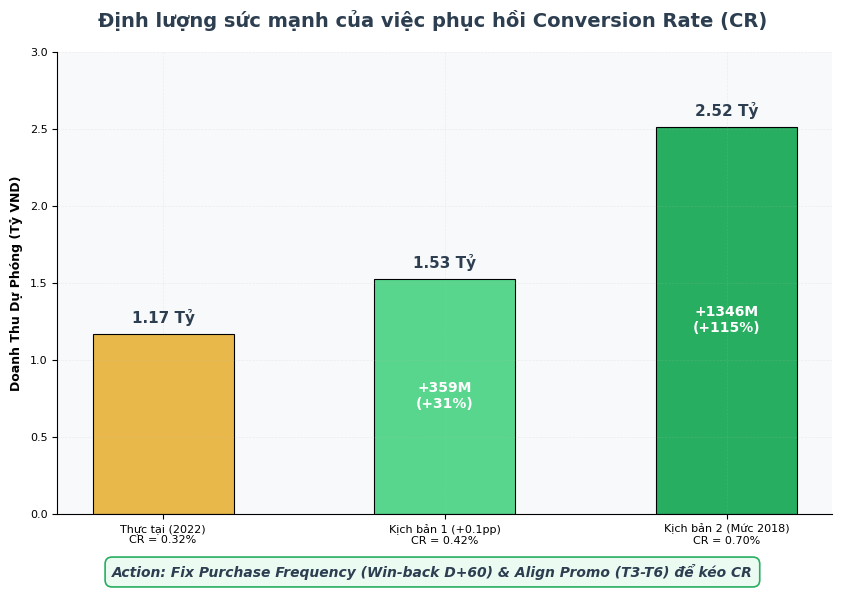

💾 M3_What_If_CR.png


In [16]:
# ══════════════════════════════════════════════════════════════════
# CELL 5 — CHART 3: WHAT-IF SCENARIOS (SỨC MẠNH CỦA CONVERSION RATE)
# ══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Định lượng sức mạnh của việc phục hồi Conversion Rate (CR)',
             fontsize=14, fontweight='bold', color=DRK, y=0.95)

scenarios = ['Thực tại (2022)\nCR = 0.32%', 'Kịch bản 1 (+0.1pp)\nCR = 0.42%', 'Kịch bản 2 (Mức 2018)\nCR = 0.70%']
rev_values = [1.17, 1.17 + 0.359, 1.17 + 1.346] # Tỷ VND
colors = [YEL, LGRN, GRN]

bars = ax.bar(scenarios, rev_values, color=colors, width=0.5, edgecolor=BLK, lw=0.8)

# Thêm số liệu lên cột
for i, bar in enumerate(bars):
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.05,
            f'{yval:.2f} Tỷ', ha='center', va='bottom', fontweight='bold', fontsize=11, color=DRK)
    if i > 0:
        uplift = rev_values[i] - rev_values[0]
        ax.text(bar.get_x() + bar.get_width()/2, yval/2,
                f'+{uplift*1000:.0f}M\n(+{(uplift/1.17)*100:.0f}%)',
                ha='center', va='center', fontweight='bold', color='white', fontsize=10)

ax.set_ylabel('Doanh Thu Dự Phóng (Tỷ VND)', fontweight='bold')
ax.set_ylim(0, 3.0)

# Insight Box
insight = "Action: Fix Purchase Frequency (Win-back D+60) & Align Promo (T3-T6) để kéo CR"
fig.text(0.5, 0.0, insight, ha='center', va='bottom', fontsize=10,
         style='italic', color=DRK, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', fc=GRE2, ec=GRN, lw=1.2))

save_fig(fig, 'M3_What_If_CR.png')


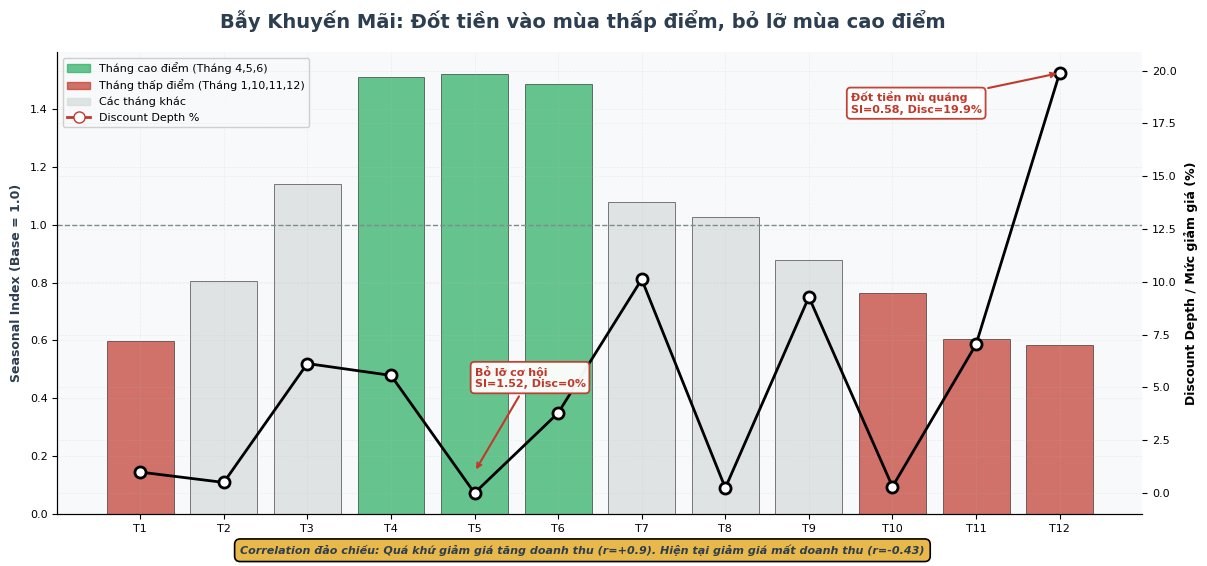

💾 M4_Promo_Mismatch.png


In [42]:
# ══════════════════════════════════════════════════════════════════
# CELL 7 — CHART 4: NGHỊCH LÝ TIMING KHUYẾN MÃI (DUAL-AXIS)
# ══════════════════════════════════════════════════════════════════
fig, ax1 = plt.subplots(figsize=(14, 6))
fig.suptitle('Bẫy Khuyến Mãi: Đốt tiền vào mùa thấp điểm, bỏ lỡ mùa cao điểm',
             fontsize=14, fontweight='bold', color=DRK, y=0.95)

# Dữ liệu tĩnh lấy từ kết quả phân tích Co Cụm (2020-2022)
months = np.arange(1, 13)
# Seasonal Index
si = [0.599, 0.805, 1.140, 1.511, 1.521, 1.487, 1.078, 1.027, 0.879, 0.764, 0.604, 0.584]
# Discount Depth (%)
dd = [0.99, 0.50, 6.13, 5.57, 0.00, 3.79, 10.12, 0.24, 9.28, 0.30, 7.04, 19.89]

# Trục 1: Seasonal Index (Bar)
color_si = []
for i, m in enumerate(months):
    if m in [4, 5, 6]: # Months 4, 5, 6 are green
        color_si.append(GRN)
    elif m in [1, 10, 11, 12]: # Months 1, 10, 11, 12 are red
        color_si.append(RED)
    else:
        # Original logic for other months
        if si[i] > 1.2:
            color_si.append(LBLU) # High season
        elif si[i] < 0.8:
            color_si.append(LORG) # Low season
        else:
            color_si.append('#D5DBDB') # Mid season

bars = ax1.bar(months, si, color=color_si, alpha=0.7, edgecolor=BLK, lw=0.5, label='Nhu cầu tự nhiên (Seasonal Index)')
ax1.set_ylabel('Seasonal Index (Base = 1.0)', fontweight='bold', color=DRK)
ax1.axhline(1.0, color=GRY, linestyle='--', lw=1)
ax1.set_xticks(months)
ax1.set_xticklabels([f"T{m}" for m in months])

# Trục 2: Discount Depth (Line)
ax2 = ax1.twinx()
ax2.plot(months, dd, color=BLK, lw=2, marker='o', ms=8, markerfacecolor='white', markeredgewidth=2, label='Discount Depth (%)')
ax2.set_ylabel('Discount Depth / Mức giảm giá (%)', fontweight='bold', color=BLK)
ax2.tick_params(axis='y', labelcolor=BLK)

# Annotations
anno_box(ax2, 'Bỏ lỡ cơ hội\nSI=1.52, Disc=0%', xy=(5, 1), xytext=(5, 5), color=RED, rad='0')
anno_box(ax2, 'Đốt tiền mù quáng\nSI=0.58, Disc=19.9%', xy=(12, 19.89), xytext=(9.5, 18), color=RED, rad='0')

# Legend chung
h_grn_bars   = mpatches.Patch(color=GRN, alpha=0.7, label='Tháng cao điểm (Tháng 4,5,6)')
h_red_bars   = mpatches.Patch(color=RED, alpha=0.7, label='Tháng thấp điểm (Tháng 1,10,11,12)')
h_other_bars = mpatches.Patch(color='#D5DBDB', alpha=0.7, label='Các tháng khác')
h_line       = mlines.Line2D([],[], color=RED, lw=2, marker='o', ms=8,
                   markerfacecolor='white', label='Discount Depth %')

handles_list = [h_grn_bars, h_red_bars, h_other_bars, h_line]
# Check if any bars are colored LBLU or LORG, if so, add them to the legend
if LBLU in color_si:
    handles_list.insert(2, mpatches.Patch(color=LBLU, alpha=0.7, label='Mùa cao điểm (theo SI)'))
if LORG in color_si:
    handles_list.insert(3, mpatches.Patch(color=LORG, alpha=0.7, label='Mùa thấp điểm (theo SI)'))

ax1.legend(handles=handles_list, loc='upper left')

insight = "Correlation đảo chiều: Quá khứ giảm giá tăng doanh thu (r=+0.9). Hiện tại giảm giá mất doanh thu (r=-0.43)"
fig.text(0.5, 0.04, insight, ha='center', va='bottom', fontsize=8, style='italic', color=DRK, fontweight='bold', bbox=dict(boxstyle='round,pad=0.5', fc=YEL, ec=BLK, lw=1.2))

save_fig(fig, 'M4_Promo_Mismatch.png')

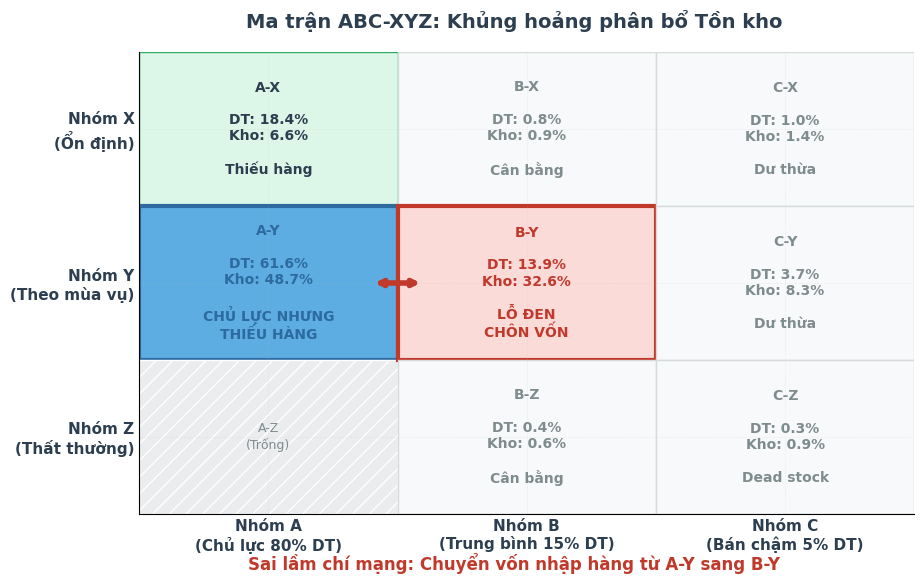

💾 M6_ABC_XYZ_Matrix.png


In [34]:
# ══════════════════════════════════════════════════════════════════
# CELL 8 — CHART 6: MA TRẬN ABC-XYZ (HEATMAP)
# ══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Ma trận ABC-XYZ: Khủng hoảng phân bổ Tồn kho',
             fontsize=14, fontweight='bold', color=DRK, y=0.95)

# Cấu hình vị trí lưới 3x3
grid = {'A': 0, 'B': 1, 'C': 2}
grid_y = {'X': 2, 'Y': 1, 'Z': 0}

# Data ma trận (Doanh thu & Tồn kho)
data_matrix = {
    'A-X': {'rev': 18.4, 'stock': 6.6, 'status': 'Thiếu hàng'},
    'A-Y': {'rev': 61.6, 'stock': 48.7, 'status': 'CHỦ LỰC NHƯNG\nTHIẾU HÀNG'},
    'B-X': {'rev': 0.8, 'stock': 0.9, 'status': 'Cân bằng'},
    'B-Y': {'rev': 13.9, 'stock': 32.6, 'status': 'LỖ ĐEN\nCHÔN VỐN'},
    'B-Z': {'rev': 0.4, 'stock': 0.6, 'status': 'Cân bằng'},
    'C-X': {'rev': 1.0, 'stock': 1.4, 'status': 'Dư thừa'},
    'C-Y': {'rev': 3.7, 'stock': 8.3, 'status': 'Dư thừa'},
    'C-Z': {'rev': 0.3, 'stock': 0.9, 'status': 'Dead stock'}
}

# Vẽ từng ô vuông (Cell)
for c_x in ['A', 'B', 'C']:
    for c_y in ['X', 'Y', 'Z']:
        key = f'{c_x}-{c_y}'
        x_pos = grid[c_x]
        y_pos = grid_y[c_y]

        if key in data_matrix:
            d = data_matrix[key]
            # Thiết lập màu sắc để làm nổi bật A-Y và B-Y
            if key == 'A-Y':
                fc = LBLU; ec = BLUE; lw = 3; tc = BLUE
            elif key == 'B-Y':
                fc = '#FADBD8'; ec = RED; lw = 3; tc = RED
            elif c_x == 'A':
                fc = GRE4; ec = GRN; lw = 1; tc = DRK
            else:
                fc = '#F8F9FA'; ec = '#D5DBDB'; lw = 1; tc = GRY

            # Vẽ hình chữ nhật
            rect = plt.Rectangle((x_pos, y_pos), 1, 1, facecolor=fc, edgecolor=ec, lw=lw)
            ax.add_patch(rect)

            # In text vào giữa ô
            text = f"{key}\n\nDT: {d['rev']}%\nKho: {d['stock']}%\n\n{d['status']}"
            ax.text(x_pos + 0.5, y_pos + 0.5, text, ha='center', va='center', fontweight='bold', color=tc, fontsize=10)
        else:
            # Các ô không có dữ liệu (Ví dụ: A-Z)
            rect = plt.Rectangle((x_pos, y_pos), 1, 1, facecolor='#EAECEE', edgecolor='white', lw=1, hatch='//')
            ax.add_patch(rect)
            ax.text(x_pos + 0.5, y_pos + 0.5, f"{key}\n(Trống)", ha='center', va='center', color=GRY)

# Căn chỉnh trục
ax.set_xlim(0, 3)
ax.set_ylim(0, 3)
ax.set_xticks([0.5, 1.5, 2.5])
ax.set_xticklabels(['Nhóm A\n(Chủ lực 80% DT)', 'Nhóm B\n(Trung bình 15% DT)', 'Nhóm C\n(Bán chậm 5% DT)'], fontweight='bold', fontsize=11, color=DRK)
ax.set_yticks([0.5, 1.5, 2.5])
ax.set_yticklabels(['Nhóm Z\n(Thất thường)', 'Nhóm Y\n(Theo mùa vụ)', 'Nhóm X\n(Ổn định)'], fontweight='bold', fontsize=11, color=DRK)
ax.tick_params(axis='both', length=0)

# Mũi tên cảnh báo sai lầm
ax.annotate('', xy=(1.1, 1.5), xytext=(0.9, 1.5), arrowprops=dict(arrowstyle='<->', color=RED, lw=4))
fig.text(0.5, 0.01, "Sai lầm chí mạng: Chuyển vốn nhập hàng từ A-Y sang B-Y", ha='center', va='bottom', fontsize=12, color=RED, fontweight='bold')

save_fig(fig, 'M6_ABC_XYZ_Matrix.png')


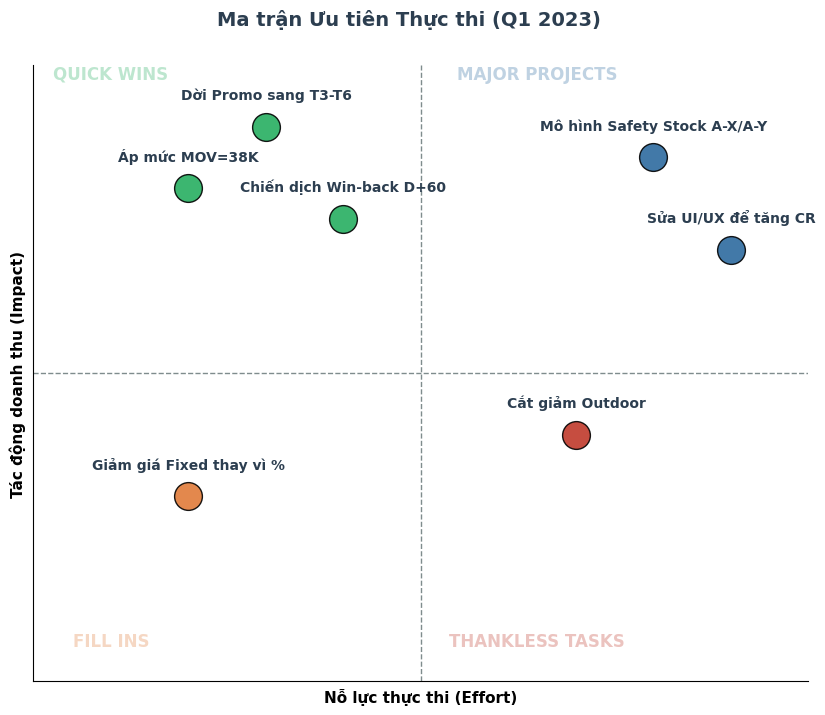

💾 M8_Impact_Effort.png


In [46]:
# ══════════════════════════════════════════════════════════════════
# CELL 9 — CHART 8: IMPACT VS EFFORT MATRIX (TỔNG HỢP GIẢI PHÁP)
# ══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle('Ma trận Ưu tiên Thực thi (Q1 2023)',
             fontsize=14, fontweight='bold', color=DRK, y=0.95)

# Chia khung 2x2
ax.axhline(5, color=GRY, linestyle='--', lw=1)
ax.axvline(5, color=GRY, linestyle='--', lw=1)

# Định nghĩa các action
actions = [
    {"name": "Áp mức MOV=38K", "effort": 2, "impact": 8, "color": GRN},
    {"name": "Dời Promo sang T3-T6", "effort": 3, "impact": 9, "color": GRN},
    {"name": "Chiến dịch Win-back D+60", "effort": 4, "impact": 7.5, "color": GRN},
    {"name": "Mô hình Safety Stock A-X/A-Y", "effort": 8, "impact": 8.5, "color": BLUE},
    {"name": "Sửa UI/UX để tăng CR", "effort": 9, "impact": 7, "color": BLUE},
    {"name": "Giảm giá Fixed thay vì %", "effort": 2, "impact": 3, "color": ORG},
    {"name": "Cắt giảm Outdoor", "effort": 7, "impact": 4, "color": RED},
]

for a in actions:
    ax.scatter(a["effort"], a["impact"], color=a["color"], s=400, edgecolors=BLK, alpha=0.9, zorder=5)
    ax.text(a["effort"], a["impact"]+0.4, a["name"], ha='center', va='bottom', fontsize=10, fontweight='bold', color=DRK)

# Quadrant labels
ax.text(1, 10, 'QUICK WINS', ha='center', va='top', fontsize=12, fontweight='bold', color=GRN, alpha=0.3)
ax.text(6.5, 10, 'MAJOR PROJECTS', ha='center', va='top', fontsize=12, fontweight='bold', color=BLUE, alpha=0.3)
ax.text(1, 0.5, 'FILL INS', ha='center', va='bottom', fontsize=12, fontweight='bold', color=ORG, alpha=0.3)
ax.text(6.5, 0.5, 'THANKLESS TASKS', ha='center', va='bottom', fontsize=12, fontweight='bold', color=RED, alpha=0.3)

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_xlabel('Nỗ lực thực thi (Effort)', fontweight='bold', fontsize=11)
ax.set_ylabel('Tác động doanh thu (Impact)', fontweight='bold', fontsize=11)
ax.set_xticks([])
ax.set_yticks([])
ax.set_facecolor('#FFFFFF')

save_fig(fig, 'M8_Impact_Effort.png')


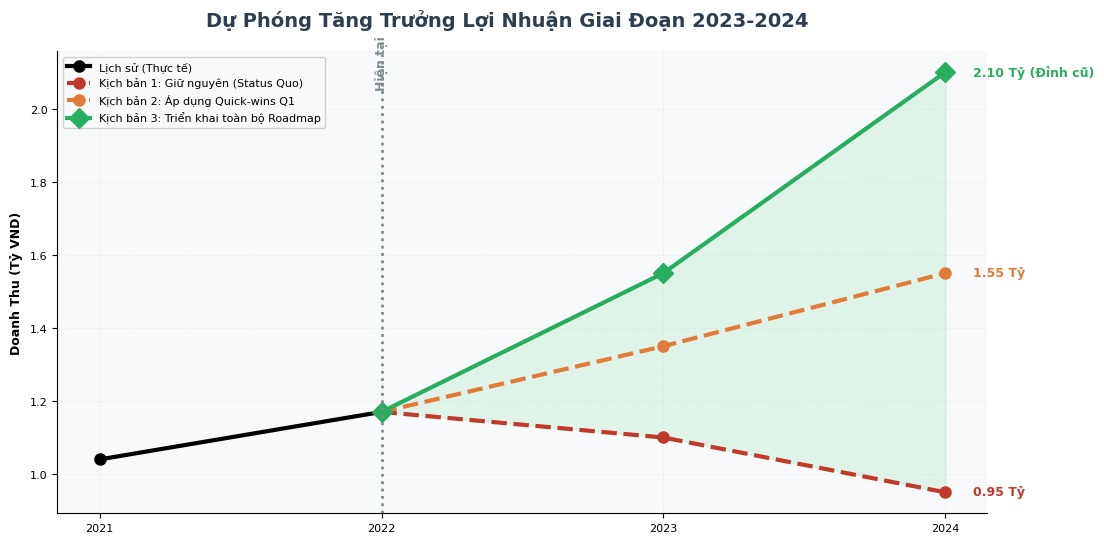

💾 M9_Projection.png


In [11]:
# ══════════════════════════════════════════════════════════════════
# CELL 10 — CHART 9: DỰ BÁO DOANH THU 2023-2024
# ══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Dự Phóng Tăng Trưởng Lợi Nhuận Giai Đoạn 2023-2024',
             fontsize=14, fontweight='bold', color=DRK, y=0.95)

years = [2021, 2022, 2023, 2024]
# Dữ liệu quá khứ
past_rev = [1.04, 1.17, np.nan, np.nan]
# Các kịch bản tương lai (Từ 2022 nối đi)
scen_base = [np.nan, 1.17, 1.10, 0.95] # Đi xuống
scen_q1   = [np.nan, 1.17, 1.35, 1.55] # Phục hồi nhẹ
scen_full = [np.nan, 1.17, 1.55, 2.10] # Vượt đỉnh

# Vẽ quá khứ
ax.plot(years, past_rev, color=BLK, lw=3, marker='o', ms=8, label='Lịch sử (Thực tế)')

# Vẽ tương lai
ax.plot(years, scen_base, color=RED, lw=3, linestyle='--', marker='o', ms=8, label='Kịch bản 1: Giữ nguyên (Status Quo)')
ax.plot(years, scen_q1, color=ORG, lw=3, linestyle='--', marker='o', ms=8, label='Kịch bản 2: Áp dụng Quick-wins Q1')
ax.plot(years, scen_full, color=GRN, lw=3, linestyle='-', marker='D', ms=10, label='Kịch bản 3: Triển khai toàn bộ Roadmap')

# Fan chart shading
ax.fill_between(years[1:], scen_base[1:], scen_full[1:], color=LGRN, alpha=0.15)

# Annotations cuối kỳ
ax.text(2024.1, scen_base[-1], '0.95 Tỷ', va='center', fontweight='bold', color=RED)
ax.text(2024.1, scen_q1[-1], '1.55 Tỷ', va='center', fontweight='bold', color=ORG)
ax.text(2024.1, scen_full[-1], '2.10 Tỷ (Đỉnh cũ)', va='center', fontweight='bold', color=GRN)

ax.set_xticks(years)
ax.set_ylabel('Doanh Thu (Tỷ VND)', fontweight='bold')
ax.legend(loc='upper left', framealpha=0.9)

# Kẻ vạch hiện tại
ax.axvline(2022, color=GRY, linestyle=':', lw=2)
ax.text(2022, 2.2, 'Hiện tại', ha='center', va='top', fontweight='bold', color=GRY, rotation=90)

save_fig(fig, 'M9_Projection.png')


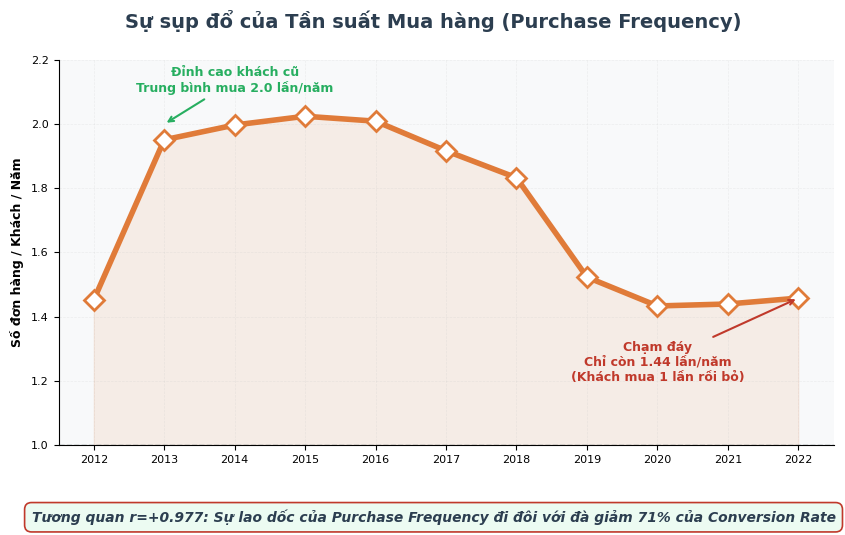

💾 D1_Purchase_Frequency_Drop.png


In [47]:
# ══════════════════════════════════════════════════════════════════
# CELL 11 — DIAGNOSTIC 1: SỰ SỤP ĐỔ CỦA PURCHASE FREQUENCY
# ══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Sự sụp đổ của Tần suất Mua hàng (Purchase Frequency)',
             fontsize=14, fontweight='bold', color=DRK, y=0.98)

# Lấy dữ liệu freq_yr từ Cell 2
years = freq_yr['year']
pf = freq_yr['Purchase_Freq']

# Vẽ Line
ax.plot(years, pf, color=ORG, lw=4, marker='D', ms=10,
        markerfacecolor='white', markeredgewidth=2)

# Tô màu gradient cảnh báo sụt giảm
ax.fill_between(years, pf, 1.0, color=ORG, alpha=0.1)

# Annotations các điểm mốc
ax.annotate('Đỉnh cao khách cũ\nTrung bình mua 2.0 lần/năm',
            xy=(2013, 2.0), xytext=(2014, 2.1),
            arrowprops=dict(arrowstyle='->', color=GRN, lw=1.5),
            color=GRN, fontweight='bold', ha='center')

ax.annotate('Chạm đáy\nChỉ còn 1.44 lần/năm\n(Khách mua 1 lần rồi bỏ)',
            xy=(2022, pf.iloc[-1]), xytext=(2020, 1.2),
            arrowprops=dict(arrowstyle='->', color=RED, lw=1.5),
            color=RED, fontweight='bold', ha='center')

ax.set_ylim(1.0, 2.2)
ax.set_xticks(years)
ax.set_ylabel('Số đơn hàng / Khách / Năm', fontweight='bold')
ax.axhline(1.0, color=GRY, linestyle='--', lw=1)

insight = "Tương quan r=+0.977: Sự lao dốc của Purchase Frequency đi đôi với đà giảm 71% của Conversion Rate"
fig.text(0.5, -0.05, insight, ha='center', va='bottom', fontsize=10,
         style='italic', color=DRK, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', fc=GRE2, ec=RED, lw=1.2))

save_fig(fig, 'D1_Purchase_Frequency_Drop.png')


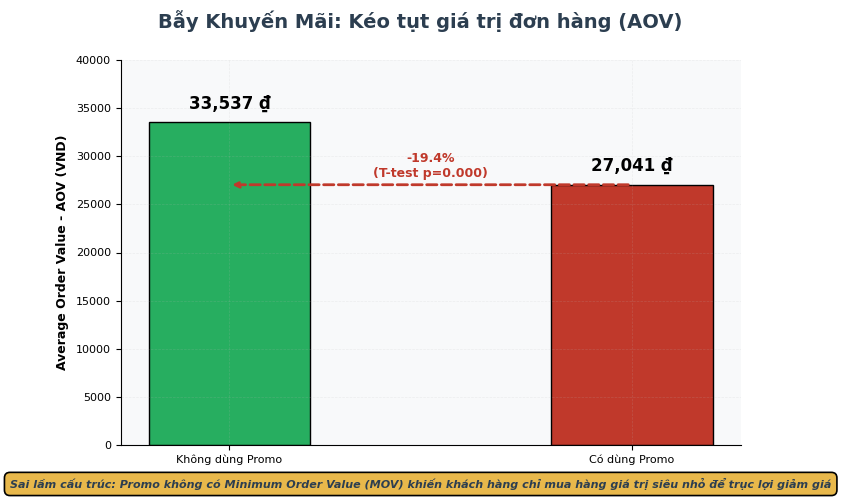

💾 D2_Promo_AOV_Trap.png


In [54]:
# ══════════════════════════════════════════════════════════════════
# CELL 12 — DIAGNOSTIC 2: BẪY AOV TRONG KHUYẾN MÃI (PROMO TRAP)
# ══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle('Bẫy Khuyến Mãi: Kéo tụt giá trị đơn hàng (AOV)',
             fontsize=14, fontweight='bold', color=DRK, y=0.98)

# Dữ liệu từ T-test (Co Cụm)
cats = ['Không dùng Promo', 'Có dùng Promo']
aov_vals = [33537, 27041] # VND (Lấy từ phân tích Promo)
colors = [GRN, RED]

bars = ax.bar(cats, aov_vals, color=colors, width=0.4, edgecolor=BLK, lw=1)

# Text hiển thị
for i, bar in enumerate(bars):
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 1000,
            f'{yval:,.0f} ₫', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Mũi tên so sánh giảm
ax.annotate('', xy=(1, 27041), xytext=(0, 27041),
            arrowprops=dict(arrowstyle='<-', color=RED, lw=2, ls='--'))
ax.text(0.5, 27500, '-19.4%\n(T-test p=0.000)', ha='center', va='bottom',
        color=RED, fontweight='bold')

ax.set_ylim(0, 40000)
ax.set_ylabel('Average Order Value - AOV (VND)', fontweight='bold')

insight = "Sai lầm cấu trúc: Promo không có Minimum Order Value (MOV) khiến khách hàng chỉ mua hàng giá trị siêu nhỏ để trục lợi giảm giá"
fig.text(0.5, 0.02, insight, ha='center', va='bottom', fontsize=8,
         style='italic', color=DRK, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', fc=YEL, ec=BLK, lw=1.2))

save_fig(fig, 'D2_Promo_AOV_Trap.png')


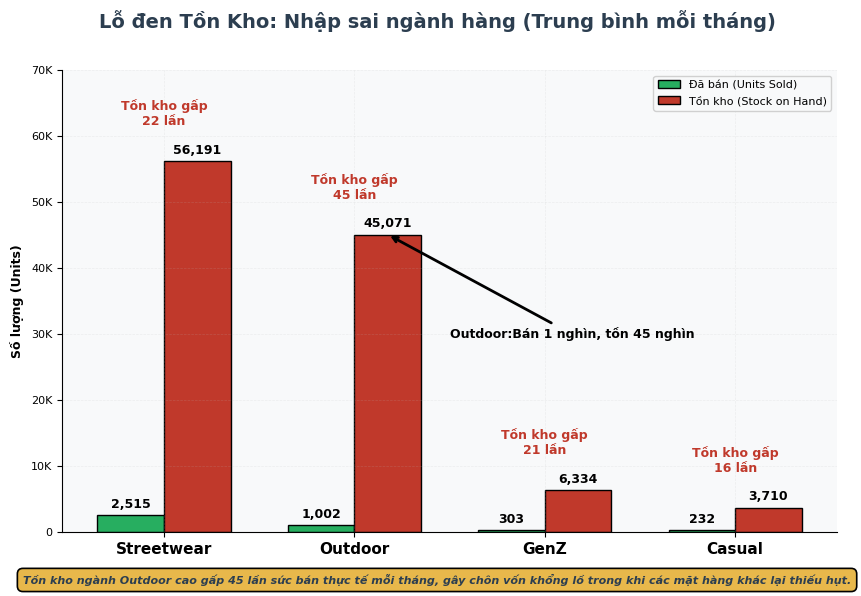

💾 D3_Sold_vs_Stock_Category.png


In [57]:
# ══════════════════════════════════════════════════════════════════
# CELL 13 — DIAGNOSTIC 3: LỆCH PHA TỒN KHO THEO NGÀNH HÀNG (SOLD vs STOCK)
# ══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Lỗ đen Tồn Kho: Nhập sai ngành hàng (Trung bình mỗi tháng)',
             fontsize=14, fontweight='bold', color=DRK, y=0.98)

# Dữ liệu Co Cụm (Trung bình mỗi tháng)
categories = ['Streetwear', 'Outdoor', 'GenZ', 'Casual']
avg_sold  = [2515, 1002, 303, 232]
avg_stock = [56191, 45071, 6334, 3710]

x = np.arange(len(categories))
width = 0.35

# Vẽ Bar
rects1 = ax.bar(x - width/2, avg_sold, width, label='Đã bán (Units Sold)', color=GRN, edgecolor=BLK)
rects2 = ax.bar(x + width/2, avg_stock, width, label='Tồn kho (Stock on Hand)', color=RED, edgecolor=BLK)

# Annotations trên bar
def autolabel(rects, is_stock=False):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:,.0f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=9)

autolabel(rects1)
autolabel(rects2, is_stock=True)

# Tính tỷ lệ Cover (Stock / Sold)
for i in range(len(categories)):
    cover = avg_stock[i] / avg_sold[i]
    ax.text(i, avg_stock[i] + 5000, f'Tồn kho gấp\n{cover:.0f} lần',
            ha='center', va='bottom', color=RED, fontweight='bold', fontsize=9)

# Highlight Outdoor
ax.annotate('Outdoor:Bán 1 nghìn, tồn 45 nghìn',
            xy=(1 + width/2, 45071), xytext=(1.5, 30000),
            arrowprops=dict(arrowstyle='->', color=BLK, lw=2),
            color=BLK, fontweight='bold', va='center')

ax.set_xticks(x)
ax.set_xticklabels(categories, fontweight='bold', fontsize=11)
ax.set_ylabel('Số lượng (Units)', fontweight='bold')
ax.set_ylim(0, 70000)
fmt_b(ax, axis='y')
ax.legend(loc='upper right', framealpha=0.9)

insight = "Tồn kho ngành Outdoor cao gấp 45 lần sức bán thực tế mỗi tháng, gây chôn vốn khổng lồ trong khi các mặt hàng khác lại thiếu hụt."
fig.text(0.5, 0.02, insight, ha='center', va='bottom', fontsize=8,
         style='italic', color=DRK, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', fc=YEL, ec=BLK, lw=1.2))

save_fig(fig, 'D3_Sold_vs_Stock_Category.png')
